<a href="https://colab.research.google.com/github/AdityaWarrier2006/TensorFlow-for-Machine-Learning/blob/main/02_04_neural_network_classification_with_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

Multiclass Classification (when one object can have multiple labels/ clases)

In [2]:
'''
pretend we are a fashion company
build a neural network to classify clothing images into different categories
use fashion_mnist (existing dataset of 60,000 training and 10,000 testing vales)
this already there in tensorflow adn has already been sorted into training and testing

https://github.com/zalandoresearch/fashion-mnist

''';

In [3]:
from tensorflow.keras.datasets import fashion_mnist

(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
'''
Label	Description
0	T-shirt/top
1	Trouser
2	Pullover
3	Dress
4	Coat
5	Sandal
6	Shirt
7	Sneaker
8	Bag
9	Ankle boot
''';

In [5]:
# show the first training sample
print("Training sample", train_data[0])
print("Training label", train_labels[0])

print("Testing sample", test_data[0])
print("Testing label", test_labels[0])

Training sample [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   

In [6]:
# check shape of single example
train_data[0].shape, train_labels[0].shape

((28, 28), ())

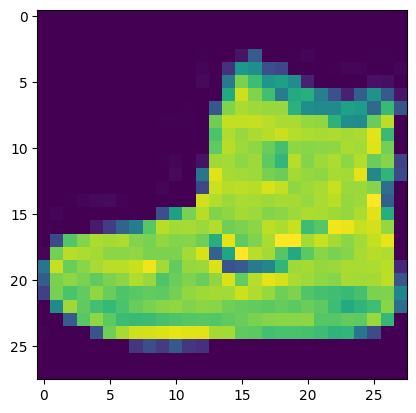

In [7]:
# plot a single sample

import matplotlib.pyplot as plt
plt.imshow(train_data[0])

In [8]:
# check our the sample's label
train_labels[0].item()

9

In [9]:
# create a new list to make the labels human readable

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]
len(class_names)

10

Text(0.5, 1.0, 'T-shirt/top')

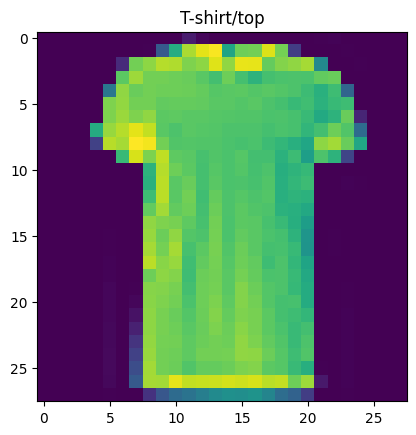

In [10]:
# Plot an example image and its label

index_of_choice = 17
plt.imshow(train_data[index_of_choice])
plt.title(class_names[train_labels[index_of_choice]])

In [11]:
# input and output shapes respectively
print(train_data[0].shape)
print(len(class_names))

(28, 28)
10


In [12]:
'''
Input shape = 28 x 28
Output shape = 10 (one per class of clothing)
Loss function = sparse_categorical_crossentropy
Output layer acivation = Softmax (not Sigmoid)
''';

In [13]:
model_11 = tf.keras.Sequential([
    # we need to flatten the 2D input of 28*28 into 1D of 784
    # so that the neurons can understand it
    tf.keras.layers.Flatten(input_shape = (28, 28)),

    tf.keras.layers.Dense(128, activation = "relu"),
    tf.keras.layers.Dense(128, activation = "relu"),
    tf.keras.layers.Dense(10, activation = "softmax")
    ])

# one hot encoding is a pre-req for categorical-cross-entropy
'''
Gemini said
Sparse Categorical Cross-Entropy is a specific version of the categorical cross-entropy loss function designed
to save you time and computer memory. It allows you to train a multi-class model using integers (like 0, 1, 2)
as your labels, rather than converting them into one-hot encoded vectors (like [1, 0, 0])
'''
model_11.compile(loss = "SparseCategoricalCrossentropy",
                 optimizer = tf.keras.optimizers.Adam(),
                 metrics = ["accuracy"])

model_11_history = model_11.fit(train_data, train_labels,
                                epochs = 10,
                                validation_data = (test_data, test_labels))

'''
validation here gives us an additional acc score on how the model performs on data
it hasn't seen yet '''

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.7353 - loss: 2.2768 - val_accuracy: 0.7297 - val_loss: 0.8593
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7781 - loss: 0.6681 - val_accuracy: 0.7910 - val_loss: 0.6569
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8022 - loss: 0.5964 - val_accuracy: 0.8030 - val_loss: 0.5828
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8163 - loss: 0.5498 - val_accuracy: 0.8249 - val_loss: 0.5696
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8283 - loss: 0.5065 - val_accuracy: 0.8125 - val_loss: 0.5350
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8381 - loss: 0.4680 - val_accuracy: 0.8394 - val_loss: 0.4645
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8480 - loss: 0.4351 - val_accuracy: 0.8403 - val_loss: 0.4744
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8530 - loss: 0.4175 -

"\nvalidation here gives us an additional acc score on how the model performs on data\nit hasn't seen yet "

In [14]:
# check the model summary
model_11.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 354,848 (1.35 MB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 236,566 (924.09 KB)

In [15]:
# check the min and max values of the training data
train_data.min().item(), train_data.max().item()

(0, 255)

Improving performace with normmalization

In [16]:
# neural nets prefer data to be normalised (values between 0-1)
# we can get our training and testing data between 0 and 1 by dividing by max

train_data_norm = train_data/ 255.0
test_data_norm = test_data/ 255.0

train_data_norm.min().item(), train_data_norm.max().item(), test_data_norm.min().item(), test_data_norm.max().item()


(0.0, 1.0, 0.0, 1.0)

In [17]:
# build a model on the normalised data

model_12 = tf.keras.Sequential([
    # flatten the inputs into a 1D array
    tf.keras.layers.Flatten(input_shape = (28, 28)),

    tf.keras.layers.Dense(128, activation = "relu"),
    tf.keras.layers.Dense(128, activation = "relu"),
    tf.keras.layers.Dense(10, activation = "softmax")
])

model_12.compile(
    loss = "SparseCategoricalCrossentropy",
    optimizer = tf.keras.optimizers.Adam(),
    metrics = ["accuracy"]
)

model_12_history = model_12.fit(train_data_norm, train_labels,
                                epochs = 10,
                                validation_data = (test_data_norm, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8258 - loss: 0.4808 - val_accuracy: 0.8471 - val_loss: 0.4320
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8680 - loss: 0.3591 - val_accuracy: 0.8525 - val_loss: 0.4029
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8789 - loss: 0.3295 - val_accuracy: 0.8719 - val_loss: 0.3574
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8863 - loss: 0.3072 - val_accuracy: 0.8665 - val_loss: 0.3586
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8924 - loss: 0.2888 - val_accuracy: 0.8780 - val_loss: 0.3517
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8971 - loss: 0.2740 - val_accuracy: 0.8810 - val_loss: 0.3428
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9019 - loss: 0.2619 - val_accuracy: 0.8794 - val_loss: 0.3355
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9047 - loss: 0.2513 - 

In [18]:
'''
# same as model 12 but only 4 neurons in each layer
model_13 = tf.keras.Sequential([
    # flatten the inputs into a 1D array
    tf.keras.layers.Flatten(input_shape = (28, 28)),

    tf.keras.layers.Dense(4, activation = "relu"),
    tf.keras.layers.Dense(4, activation = "relu"),
    tf.keras.layers.Dense(10, activation = "softmax")
])

model_13.compile(
    loss = "SparseCategoricalCrossentropy",
    optimizer = tf.keras.optimizers.Adam(),
    metrics = ["accuracy"]
)

model_13_history = model_13.fit(train_data_norm, train_labels,
                                epochs = 10,
                                validation_data = (test_data_norm, test_labels))

''';

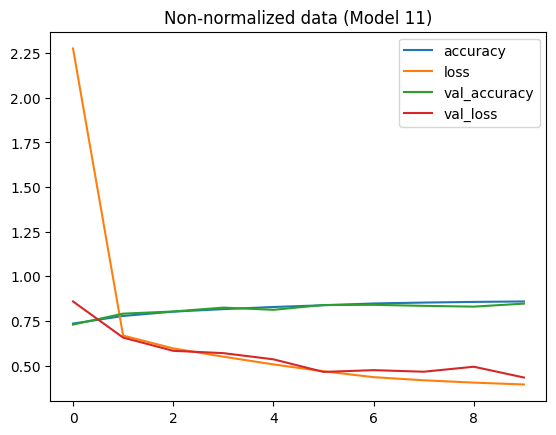

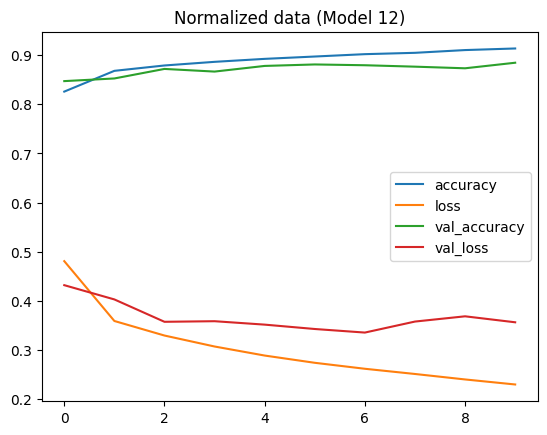

In [19]:
import pandas as pd

# plot non-normalized data loss curves
pd.DataFrame(model_11_history.history).plot(title = "Non-normalized data (Model 11)");

# plot normalized data loss curves
pd.DataFrame(model_12_history.history).plot(title = "Normalized data (Model 12)");

# val- validation


In [20]:
model_11.summary(), model_12.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 354,848 (1.35 MB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 354,848 (1.35 MB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 236,566 (924.09 KB)

(None, None)

Finding the ideal learing rate

In [21]:
model_14 = tf.keras.Sequential([
    # flatten the inputs into a 1D array
    tf.keras.layers.Flatten(input_shape = (28, 28)),

    tf.keras.layers.Dense(128, activation = "relu"),
    tf.keras.layers.Dense(128, activation = "relu"),
    tf.keras.layers.Dense(10, activation = "softmax")
])

model_14.compile(
    loss = "SparseCategoricalCrossentropy",
    optimizer = tf.keras.optimizers.Adam(),
    metrics = ["accuracy"])

# create the learing rate call back
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))


model_14_history = model_14.fit(train_data_norm, train_labels,
                                epochs = 40,
                                validation_data = (test_data_norm, test_labels),
                                callbacks = lr_scheduler,
                                verbose = 1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7787 - loss: 0.6695 - val_accuracy: 0.8191 - val_loss: 0.5076 - learning_rate: 1.0000e-04
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8462 - loss: 0.4412 - val_accuracy: 0.8400 - val_loss: 0.4510 - learning_rate: 1.1220e-04
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8597 - loss: 0.3977 - val_accuracy: 0.8468 - val_loss: 0.4274 - learning_rate: 1.2589e-04
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8687 - loss: 0.3705 - val_accuracy: 0.8580 - val_loss: 0.3936 - learning_rate: 1.4125e-04
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8743 - loss: 0.3514 - val_accuracy: 0.8614 - val_loss: 0.3894 - learning_rate: 1.5849e-04
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8798 - loss: 0.3338 - val_accuracy: 0.8685 - val_loss: 0.3653 - learning_rate: 1.7783e-04
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/ste

'\nFor ideal training rate, we look for the point where the loss is still actively\ndecreasing and is at its lowest before it starts to explode or become unstable again.\nPick a value that is half a step or one step to the left of the absolute minimum.\n'

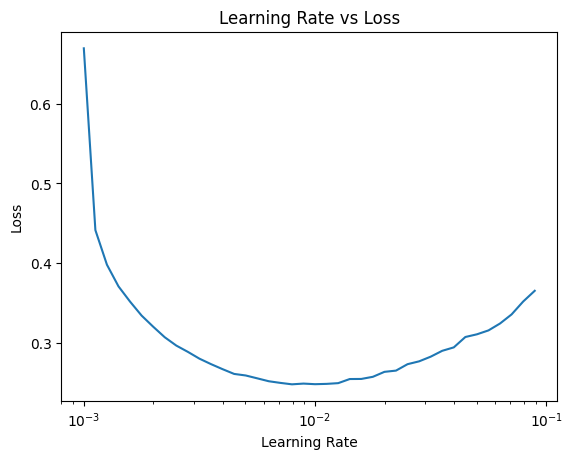

In [22]:
# plot the learning rate decay curve

import numpy as np
import matplotlib.pyplot as plt

lrs  = 1e-3 * (10**(tf.range(40)/20))
plt.semilogx(lrs, model_14_history.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning Rate vs Loss")

'''
For ideal training rate, we look for the point where the loss is still actively
decreasing and is at its lowest before it starts to explode or become unstable again.
Pick a value that is half a step or one step to the left of the absolute minimum.
'''

In [23]:
# Refit the model with ideal learning rate
# ideal lr = 0.01 (from plot above)


model_15 = tf.keras.Sequential([
    # flatten the inputs into a 1D array
    tf.keras.layers.Flatten(input_shape = (28, 28)),

    tf.keras.layers.Dense(128, activation = "relu"),
    tf.keras.layers.Dense(128, activation = "relu"),
    tf.keras.layers.Dense(10, activation = "softmax")
])

model_15.compile(
    loss = "SparseCategoricalCrossentropy",
    optimizer = tf.keras.optimizers.Adam(),
    metrics = ["accuracy"]
)

model_15_history = model_15.fit(train_data_norm, train_labels,
                                epochs = 10,
                                validation_data = (test_data_norm, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8256 - loss: 0.4862 - val_accuracy: 0.8406 - val_loss: 0.4340
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8682 - loss: 0.3622 - val_accuracy: 0.8666 - val_loss: 0.3751
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8799 - loss: 0.3270 - val_accuracy: 0.8708 - val_loss: 0.3597
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8872 - loss: 0.3059 - val_accuracy: 0.8713 - val_loss: 0.3618
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8926 - loss: 0.2884 - val_accuracy: 0.8758 - val_loss: 0.3420
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8971 - loss: 0.2731 - val_accuracy: 0.8734 - val_loss: 0.3569
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9013 - loss: 0.2606 - val_accuracy: 0.8763 - val_loss: 0.3443
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9064 - loss: 0.2487 - 

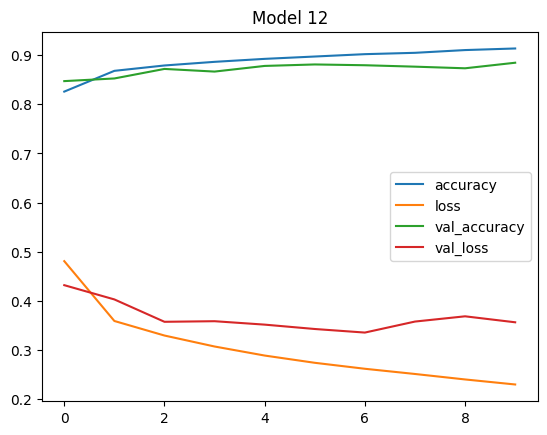

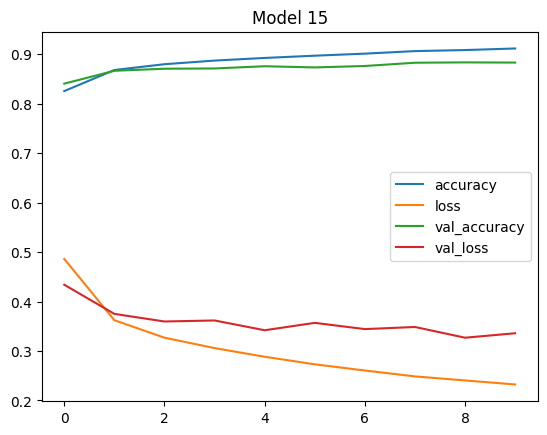

In [24]:
pd.DataFrame(model_12_history.history).plot(title = "Model 12");
pd.DataFrame(model_15_history.history).plot(title = "Model 15");


Creating the confusion matrix

In [25]:
y_preds = model_15.predict(test_data_norm)
y_preds[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([4.2509392e-09, 3.9635374e-08, 2.6396579e-10, 2.2137450e-09,
       6.0045779e-10, 2.2038637e-05, 4.5828448e-09, 6.5959728e-04,
       3.0765184e-09, 9.9931836e-01], dtype=float32)

Prettyfing our confusion matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


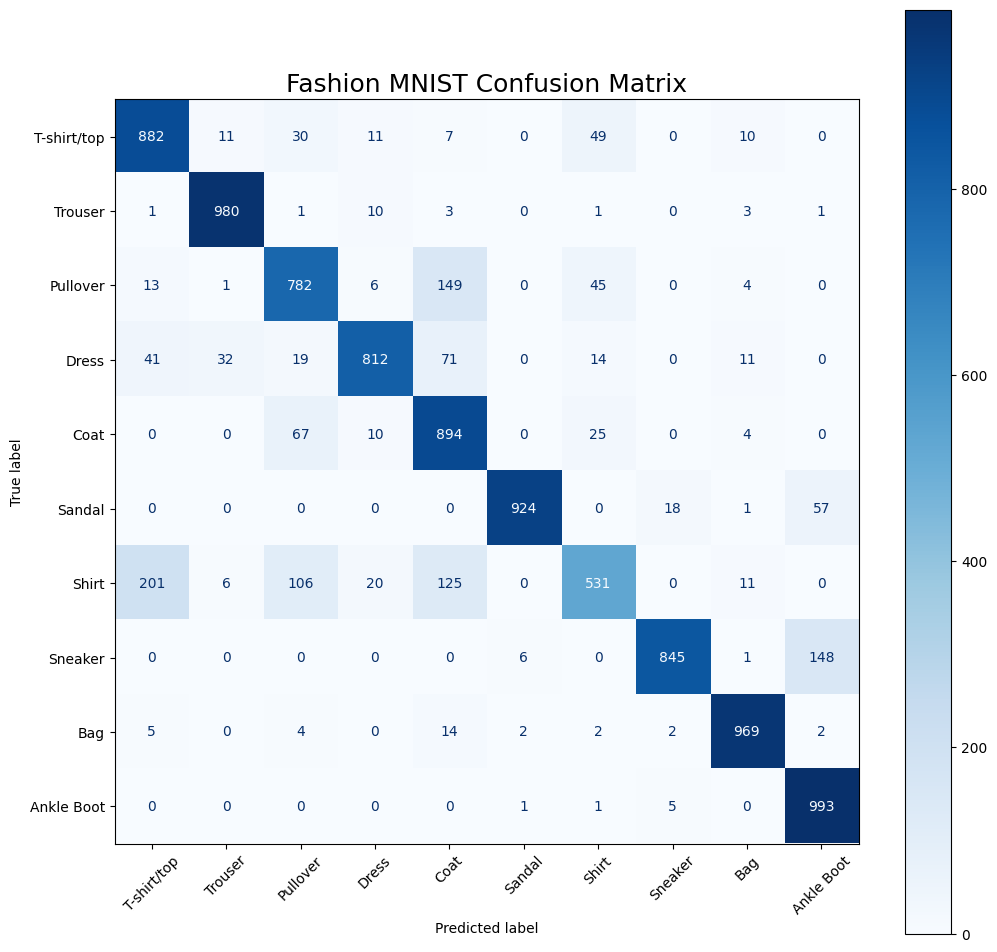

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Get the predictions
# Use argmax to get the index of the highest probability
y_probs = model_15.predict(test_data)
y_preds = y_probs.argmax(axis=1)

# 2. Create the Figure and Axes first
# This gives you full control over the size for your report
fig, ax = plt.subplots(figsize=(12, 12))

# 3. Plot the Confusion Matrix
# We use 'from_predictions' to do the math and the drawing in one go
disp = ConfusionMatrixDisplay.from_predictions(
    y_true=test_labels,
    y_pred=y_preds,
    display_labels=class_names, # Uses your ['T-shirt/top', 'Trouser', ...] list
    cmap=plt.cm.Blues,
    xticks_rotation=45,
    values_format='d',          # 'd' for decimal integers
    ax=ax                       # Tell it to draw on our pre-defined axes
)

# 4. Final Touch
ax.set_title("Fashion MNIST Confusion Matrix", size=18)
plt.show()

What patterns is our model learning?

In [27]:
# find layers of our most recent model

model_15.layers

[<Flatten name=flatten_3, built=True>,
 <Dense name=dense_9, built=True>,
 <Dense name=dense_10, built=True>,
 <Dense name=dense_11, built=True>]

In [28]:
# extract a layer
model_14.layers[1]

<Dense name=dense_6, built=True>

In [29]:
# get the patterns of a layer in our networks

weights, biases = model_14.layers[1].get_weights()
weights, weights.shape


(array([[-0.0233379 ,  0.7347121 ,  0.05987038, ...,  0.02816714,
         -0.46534464,  0.1961576 ],
        [-0.483839  , -0.56991005, -0.71499264, ...,  0.4142461 ,
         -0.01360708,  2.1593258 ],
        [-0.06935473, -0.63223046, -0.26242605, ..., -0.20379567,
         -0.23659752,  1.4750662 ],
        ...,
        [-1.0047143 , -0.6860576 ,  0.818556  , ...,  0.5489824 ,
          0.43759513, -0.5946339 ],
        [-0.7368253 ,  0.2806965 ,  0.8597315 , ...,  0.5483307 ,
          0.29030392,  0.14755106],
        [-0.7541621 , -0.24459805,  0.6191342 , ...,  0.33804876,
         -0.87196684,  0.41464633]], dtype=float32),
 (784, 128))

In [30]:
# check our bias vector

biases, biases.shape

(array([ 1.35510242e+00, -5.75624049e-01, -3.51196200e-01, -3.70590240e-02,
         5.63184798e-01,  1.41549736e-01, -6.15454674e-01, -2.41257930e+00,
         1.22103179e+00,  3.78054529e-02, -6.77861452e-01,  1.72470427e+00,
         3.36584821e-02,  7.91791141e-01,  1.48837805e+00, -3.02045375e-01,
         6.82466701e-02, -2.98053563e-01,  1.38664043e+00,  4.35897380e-01,
         1.10967076e+00,  8.35950911e-01, -1.27281845e+00, -3.38322967e-01,
         8.31851214e-02,  1.71779072e+00,  1.84519017e+00, -5.25951028e-01,
        -4.37296689e-01, -2.23610654e-01, -3.18410158e-01,  1.76421797e+00,
        -2.01157141e+00,  1.14929795e+00, -2.47107363e+00,  1.50389683e+00,
        -5.46429515e-01,  1.36477447e+00, -3.99261415e-01,  2.88288325e-01,
         6.94068745e-02,  1.45974159e+00,  5.19921422e-01,  2.19490677e-01,
         2.86134630e-01,  1.09148705e+00, -1.41534045e-01, -9.17416289e-02,
         3.06487346e+00,  8.52196753e-01,  9.47527707e-01, -6.16734803e-01,
        -2.7

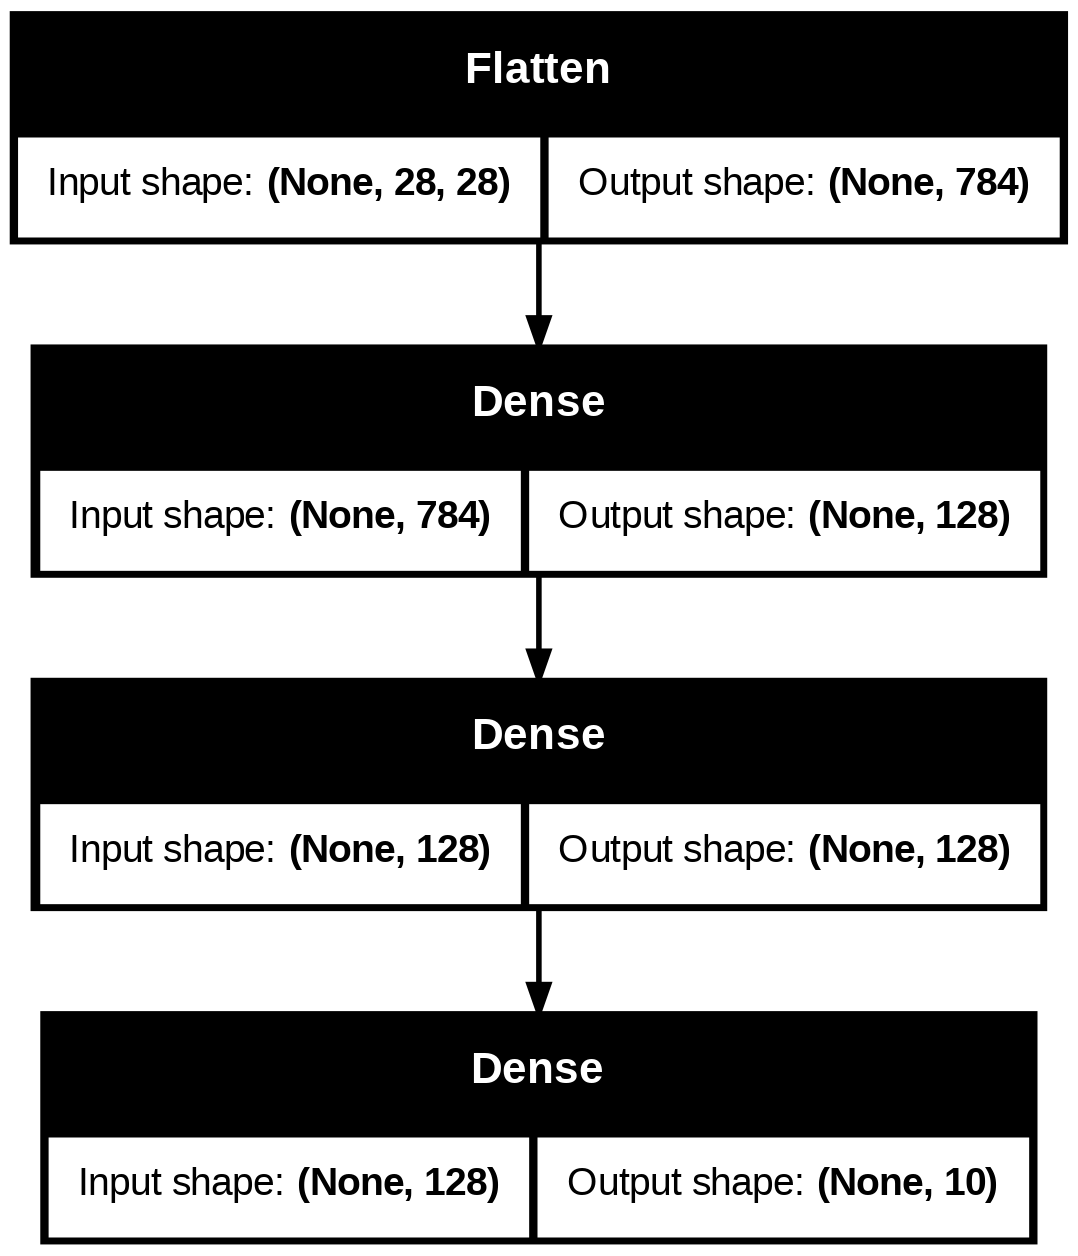

In [31]:
# another way to view our deep learning model

from tensorflow.keras.utils import plot_model
# see the inputs and outputs of each layer
plot_model(model_14, show_shapes = True)